# Superstore Data Cleaning, EDA & Business Analysis

## Objective

To clean and prepare the Superstore dataset using Python and Pandas, perform exploratory data analysis (EDA), identify sales and profit patterns, and generate meaningful business insights related to products, customers, categories, regions, states, and time-based performance.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Load Dataset
df=pd.read_csv("superstore.csv")

###Understanding Dataset:

In [7]:
#displays top 5 rows:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [8]:
#Identify Shape :no. of rows and cols
df.shape

(10800, 21)

In [9]:
#Display Columns :
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [10]:
#Show Statistical Values
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df.nunique()

,0
Row ID,10001
Order ID,5015
Order Date,1236
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531


###Detecting and Handling null values:

In [12]:
#Finding Null/Na Values:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,806
Ship Date,806
Ship Mode,806
Customer ID,806
Customer Name,806
Segment,806
Country,806
City,806


Interpretation:

The initial missing-value analysis showed that 302 records had missing values across almost all columns. Postal Code had 313 missing values. The consistent pattern of missing values across 302 records suggested that these were not ordinary isolated missing values but malformed or incomplete records requiring further investigation.



In [13]:
null_percentage = (df.isnull().sum() / len(df)) * 100

print(null_percentage.sort_values(ascending=False))



Postal Code      7.564815
Ship Mode        7.462963
Ship Date        7.462963
Customer ID      7.462963
Order Date       7.462963
Product ID       7.462963
Category         7.462963
Segment          7.462963
Customer Name    7.462963
Country          7.462963
City             7.462963
State            7.462963
Region           7.462963
Sales            7.462963
Quantity         7.462963
Sub-Category     7.462963
Product Name     7.462963
Discount         7.462963
Profit           7.462963
Order ID         0.000000
Row ID           0.000000
dtype: float64


In [14]:
df[df["Order Date"].isnull()].head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#Drop Null values:
df=df.dropna(subset=["Order Date"])


Interpretation:

Since Order Date is a fundamental field for transaction-level analysis and the records with missing Order Date were found to be largely incomplete, these 302 malformed records were removed. This reduced the dataset from 9,994 records to approximately 9,692 valid records.

###Removing Duplicate rows:

In [16]:
#Display Duplicate rows
df.duplicated().sum()

np.int64(0)

In [17]:
#Remove Duplicate Rows:
df=df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

The dataset contains no completely duplicated rows. Therefore, no duplicate records need to be removed based on exact row-level duplication. This indicates that each row is unique based on the combination of values across all 21 columns.

In [19]:
#Shows information about Dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   object 
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity     

In [20]:
#changes dtype text to datetime:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [21]:
df[["Order Date","Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


Interpretation:

The Order Date and Ship Date columns have been converted from text/object format to datetime format. This allows us to perform date-based analysis such as monthly sales, yearly sales, quarterly trends, and shipping-duration calculations.

###Feature Engineering:

####Extract Shipping Days:

In [22]:
# Calculate the number of days between the order date and ship date
df["Shipping Days"]=df["Ship Date"]-df["Order Date"]

Interpretation:

The Shipping Days column represents the number of days between when an order was placed and when it was shipped. This metric will allow us to analyze shipping performance and investigate whether shipping duration varies by shipping mode, region, category, or other business dimensions.

In [23]:
# Display the order date, ship date, and calculated shipping days
df[["Order Date", "Ship Date", "Shipping Days"]].head()


,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3 days
1,2017-11-08,2017-11-11,3 days
2,2017-06-12,2017-06-16,4 days
3,2016-10-11,2016-10-18,7 days
4,2016-10-11,2016-10-18,7 days


In [24]:
df["Shipping Days"]=df["Shipping Days"].astype(int)

####Extract Year and Month

In [25]:
# Extract year from Order Date
df['Year'] = df['Order Date'].dt.year

# Extract month number from Order Date
df['Month'] = df['Order Date'].dt.month

# Extract month name from Order Date
df['Month_Name'] = df['Order Date'].dt.month_name()

# Display the new columns
df[['Order Date', 'Year', 'Month', 'Month_Name']].head()

,Order Date,Year,Month,Month_Name
0,2017-11-08,2017,11,November
1,2017-11-08,2017,11,November
2,2017-06-12,2017,6,June
3,2016-10-11,2016,10,October
4,2016-10-11,2016,10,October


In [26]:
# Create a Year-Month column for time-series analysis
df['Year_Month'] = df['Order Date'].dt.to_period('M')

# Display the result
df[['Order Date', 'Year', 'Month', 'Month_Name', 'Year_Month']].head()

,Order Date,Year,Month,Month_Name,Year_Month
0,2017-11-08,2017,11,November,2017-11
1,2017-11-08,2017,11,November,2017-11
2,2017-06-12,2017,6,June,2017-06
3,2016-10-11,2016,10,October,2016-10
4,2016-10-11,2016,10,October,2016-10


###Detecting Outliers:

In [27]:
# Select the main numerical columns for analysis
numeric_cols=["Sales","Profit","Quantity","Shipping Days","Discount"]

# Generate summary statistics
df[numeric_cols].describe()

,Sales,Profit,Quantity,Shipping Days,Discount
count,9994.000000,9994.000000,9994.000000,9.994000e+03,9994.000000
mean,229.858001,28.656896,3.789574,3.420122e+14,0.156203
std,623.245101,234.260108,2.225110,1.509929e+14,0.206452
min,0.444000,-6599.978000,1.000000,0.000000e+00,0.000000
25%,17.280000,1.728750,2.000000,2.592000e+14,0.000000
50%,54.490000,8.666500,3.000000,3.456000e+14,0.200000
75%,209.940000,29.364000,5.000000,4.320000e+14,0.200000
max,22638.480000,8399.976000,14.000000,6.048000e+14,0.800000


The descriptive statistics provide an overview of the main numerical variables. They show the central tendency, spread, minimum, and maximum values of sales, quantity, discount, profit, and shipping duration. This gives us an initial understanding of the dataset before performing deeper analysis.

In [28]:
numeric_cols

['Sales', 'Profit', 'Quantity', 'Shipping Days', 'Discount']

IQR-based outlier detection was performed on numerical variables. Potential outliers were identified in Sales, Profit, Quantity, and Discount, while Shipping Days showed no IQR-based outliers. The identified observations were retained pending business-context validation rather than being automatically removed.

In [29]:
# List of numerical columns for which we want to detect potential outliers
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']

# Loop through each numerical column
for col in numeric_cols:

    # Calculate the first quartile (25th percentile)
    Q1 = df[col].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = df[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Calculate the lower and upper bounds using the IQR rule
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identify observations outside the calculated bounds
    outliers = df[
        (df[col] < lower) | (df[col] > upper)
    ]

    # Display the outlier information for each column
    print(f"\n{col}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)}")

    # Display the 5 smallest and 5 largest outlier values
    print("Smallest outliers:", outliers[col].sort_values().head(5).tolist())
    print("Largest outliers:", outliers[col].sort_values(ascending=False).head(5).tolist())


Sales
Lower bound: -271.71
Upper bound: 498.93
Number of outliers: 1167
Smallest outliers: [499.168, 499.584, 499.95, 499.98, 499.99]
Largest outliers: [22638.48, 17499.95, 13999.96, 11199.968, 10499.97]

Quantity
Lower bound: -2.50
Upper bound: 9.50
Number of outliers: 170
Smallest outliers: [10.0, 10.0, 10.0, 10.0, 10.0]
Largest outliers: [14.0, 14.0, 14.0, 14.0, 14.0]

Discount
Lower bound: -0.30
Upper bound: 0.50
Number of outliers: 856
Smallest outliers: [0.6, 0.6, 0.6, 0.6, 0.6]
Largest outliers: [0.8, 0.8, 0.8, 0.8, 0.8]

Profit
Lower bound: -39.72
Upper bound: 70.82
Number of outliers: 1881
Smallest outliers: [-6599.978, -3839.9904, -3701.8928, -3399.98, -2929.4845]
Largest outliers: [8399.976, 6719.9808, 5039.9856, 4946.37, 4630.4755]

Shipping Days
Lower bound: 0.00
Upper bound: 691200000000000.00
Number of outliers: 0
Smallest outliers: []
Largest outliers: []


IQR-based outlier detection identified potential outliers in Sales, Profit, Quantity, and Discount, while no outliers were detected in Shipping Days. Since these extreme observations may represent legitimate business transactions rather than data-entry errors, they were retained for further analysis.

----

##EDA->

In [30]:
# Calculate the main business metrics

# Total Sales
total_sales = df['Sales'].sum()

# Total Profit
total_profit = df['Profit'].sum()

# Total Quantity Sold
total_quantity = df['Quantity'].sum()

# Total Orders
total_orders = df['Order ID'].nunique()

# Total Customers
total_customers = df['Customer ID'].nunique()

# Average Order Value
average_order_value = total_sales / total_orders

# Profit Margin
profit_margin = (total_profit / total_sales) * 100


# Display the results
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873.0
Total Orders: 5009
Total Customers: 793
Average Order Value: 458.61
Profit Margin: 12.47 %


Overall Business Performance: The dataset contains 5,009 unique orders from 793 customers, generating $2.30M in sales and $286.4K in profit. The average order value is $458.61, with an overall profit margin of 12.47%.

###Category Analysis:

In [31]:
# Analyze sales, profit, quantity and orders by category
category_analysis=df.groupby("Category")[["Sales","Profit","Quantity"]].sum()

# Add number of unique orders for each category
category_analysis["Orders"] = df.groupby("Category")["Order ID"].nunique()


In [32]:
# Calculate profit margin for each category

category_analysis["Profit_Margin_%"] = (
    category_analysis["Profit"]
    / category_analysis["Sales"]
) * 100

category_analysis

,Sales,Profit,Quantity,Orders,Profit_Margin_%
Category,,,,,
Furniture,741999.7953,18451.2728,8028.0,1764,2.486695
Office Supplies,719047.0320,122490.8008,22906.0,3742,17.035158
Technology,836154.0330,145454.9481,6939.0,1544,17.395712


### Category Insights

- Technology generated the highest sales at approximately $836K and the highest profit at approximately $145K.
- Office Supplies had the highest quantity sold and the highest number of orders.
- Furniture generated approximately $742K in sales but only about $18K in profit.
- The category results show that higher sales volume does not necessarily result in higher profitability.
- Technology and Office Supplies contributed substantially more profit than Furniture.

---
###Sub-Category Analysis:

In [33]:
# Analyze sales, profit and quantity by sub-category

subcategory_analysis = df.groupby("Sub-Category")[[
    "Sales",
    "Profit",
    "Quantity"
]].sum()

# Add number of unique orders
subcategory_analysis["Orders"] = (
    df.groupby("Sub-Category")["Order ID"].nunique()
)

# Sort by sales
subcategory_analysis = subcategory_analysis.sort_values(
    "Sales",
    ascending=False
)

subcategory_analysis

,Sales,Profit,Quantity,Orders
Sub-Category,,,,
Phones,330007.0540,44515.7306,3289.0,814
Chairs,328449.1030,26590.1663,2356.0,576
Storage,223843.6080,21278.8264,3158.0,777
Tables,206965.5320,-17725.4811,1241.0,307
Binders,203412.7330,30221.7633,5974.0,1316
Machines,189238.6310,3384.7569,440.0,112
Accessories,167380.3180,41936.6357,2976.0,718
Copiers,149528.0300,55617.8249,234.0,68
Bookcases,114879.9963,-3472.5560,868.0,224


In [34]:
# Calculate profit margin for each sub-category

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Profit"]
    / subcategory_analysis["Sales"]
) * 100

subcategory_analysis

,Sales,Profit,Quantity,Orders,Profit_Margin_%
Sub-Category,,,,,
Phones,330007.0540,44515.7306,3289.0,814,13.489327
Chairs,328449.1030,26590.1663,2356.0,576,8.095673
Storage,223843.6080,21278.8264,3158.0,777,9.506113
Tables,206965.5320,-17725.4811,1241.0,307,-8.564460
Binders,203412.7330,30221.7633,5974.0,1316,14.857361
Machines,189238.6310,3384.7569,440.0,112,1.788618
Accessories,167380.3180,41936.6357,2976.0,718,25.054700
Copiers,149528.0300,55617.8249,234.0,68,37.195585
Bookcases,114879.9963,-3472.5560,868.0,224,-3.022768


In [35]:
# Top 5 sub-categories by profit

top_5_profit = subcategory_analysis.sort_values(
    "Profit",
    ascending=False
).head(5)

print("Top 5 Sub-Categories by Profit:")
display(top_5_profit)


# Bottom 5 sub-categories by profit

bottom_5_profit = subcategory_analysis.sort_values(
    "Profit",
    ascending=True
).head(5)

print("Bottom 5 Sub-Categories by Profit:")
display(bottom_5_profit)

Top 5 Sub-Categories by Profit:


,Sales,Profit,Quantity,Orders,Profit_Margin_%
Sub-Category,,,,,
Copiers,149528.030,55617.8249,234.0,68,37.195585
Phones,330007.054,44515.7306,3289.0,814,13.489327
Accessories,167380.318,41936.6357,2976.0,718,25.054700
Paper,78479.206,34053.5693,5178.0,1191,43.391837
Binders,203412.733,30221.7633,5974.0,1316,14.857361


Bottom 5 Sub-Categories by Profit:


,Sales,Profit,Quantity,Orders,Profit_Margin_%
Sub-Category,,,,,
Tables,206965.5320,-17725.4811,1241.0,307,-8.564460
Bookcases,114879.9963,-3472.5560,868.0,224,-3.022768
Supplies,46673.5380,-1189.0995,647.0,187,-2.547695
Fasteners,3024.2800,949.5182,914.0,215,31.396504
Machines,189238.6310,3384.7569,440.0,112,1.788618


### Sub-Category Insights

- Phones generated the highest sales, followed closely by Chairs.
- Copiers generated the highest total profit and had a strong profit margin.
- Tables generated significant sales but resulted in the highest overall loss among the sub-categories.
- Bookcases and Supplies also recorded negative total profit.
- Labels, Paper, and Envelopes had relatively high profit margins.
- Machines generated substantial sales but had a relatively low profit margin, showing that high sales do not always translate into high profitability.

---
###Customers Analysis:

In [36]:
# Analyze customer performance
customer_analysis=df.groupby(["Customer ID","Customer Name"]).agg(
                  total_sales=("Sales","sum"),
                  total_profit=("Profit","sum"),
                  total_Quantity=("Quantity","sum"),
                  total_orders=("Order ID","nunique")
).reset_index()

customer_analysis

,Customer ID,Customer Name,total_sales,total_profit,total_Quantity,total_orders
0,AA-10315,Alex Avila,5563.560,-362.8825,30.0,5
1,AA-10375,Allen Armold,1056.390,277.3824,41.0,9
2,AA-10480,Andrew Allen,1790.512,435.8274,36.0,4
3,AA-10645,Anna Andreadi,5086.935,857.8033,64.0,6
4,AB-10015,Aaron Bergman,886.156,129.3465,13.0,3
...,...,...,...,...,...,...
788,XP-21865,Xylona Preis,2374.658,621.2300,100.0,11
789,YC-21895,Yoseph Carroll,5454.350,1305.6290,31.0,5
790,YS-21880,Yana Sorensen,6720.444,1778.2923,58.0,8
791,ZC-21910,Zuschuss Carroll,8025.707,-1032.1490,105.0,13


In [37]:
# Top 10 customers by total sales

top_sales_customers = customer_analysis.sort_values(
    by='total_sales',
    ascending=False
).head(10)

# Display the result
top_sales_customers

,Customer ID,Customer Name,total_sales,total_profit,total_Quantity,total_orders
700,SM-20320,Sean Miller,25043.050,-1980.7393,50.0,5
741,TC-20980,Tamara Chand,19052.218,8981.3239,42.0,5
621,RB-19360,Raymond Buch,15117.339,6976.0959,71.0,6
730,TA-21385,Tom Ashbrook,14595.620,4703.7883,36.0,4
6,AB-10105,Adrian Barton,14473.571,5444.8055,73.0,10
434,KL-16645,Ken Lonsdale,14175.229,806.8550,113.0,12
669,SC-20095,Sanjit Chand,14142.334,5757.4119,87.0,9
327,HL-15040,Hunter Lopez,12873.298,5622.4292,50.0,6
683,SE-20110,Sanjit Engle,12209.438,2650.6769,78.0,11
131,CC-12370,Christopher Conant,12129.072,2177.0493,34.0,5


### Customer Sales Insights

- Sean Miller generated the highest total sales at approximately $25.04K.
- Tamara Chand ranked second with approximately $19.05K in sales.
- The top 10 customers generated sales ranging from approximately $12.13K to $25.04K.
- Sean Miller had the highest sales but recorded a negative total profit of approximately -$1.98K, showing that high sales do not necessarily result in profitability.
- Several high-sales customers generated positive profit, including Tamara Chand, Raymond Buch, and Hunter Lopez.

In [38]:
# Top 10 customers by total profit

top_profit_customers = customer_analysis.sort_values(
    by='total_profit',
    ascending=False
).head(10)

# Display the result
top_profit_customers

,Customer ID,Customer Name,total_sales,total_profit,total_Quantity,total_orders
741,TC-20980,Tamara Chand,19052.218,8981.3239,42.0,5
621,RB-19360,Raymond Buch,15117.339,6976.0959,71.0,6
669,SC-20095,Sanjit Chand,14142.334,5757.4119,87.0,9
327,HL-15040,Hunter Lopez,12873.298,5622.4292,50.0,6
6,AB-10105,Adrian Barton,14473.571,5444.8055,73.0,10
730,TA-21385,Tom Ashbrook,14595.620,4703.7883,36.0,4
160,CM-12385,Christopher Martinez,8954.020,3899.8904,34.0,4
424,KD-16495,Keith Dawkins,8181.256,3038.6254,84.0,12
48,AR-10540,Andy Reiter,6608.448,2884.6208,33.0,6
234,DR-12940,Daniel Raglin,8350.868,2869.0760,57.0,8


### Customer Profit Insights

- Tamara Chand generated the highest total profit at approximately $8.98K.
- Raymond Buch generated the second-highest profit at approximately $6.98K.
- The top 10 most profitable customers generated positive profit.
- Tamara Chand generated approximately $19.05K in sales and $8.98K in profit, indicating a strong contribution to overall profitability.
- The customer results show that customers with high sales can have different levels of profitability.

In [39]:
# Identify customers with negative total profit

loss_customers = customer_analysis[
    customer_analysis['total_profit'] < 0
].sort_values(
    by='total_profit',
    ascending=True
)

# Display the 10 customers with the highest losses
loss_customers.head(10)

,Customer ID,Customer Name,total_sales,total_profit,total_Quantity,total_orders
180,CS-12505,Cindy Stewart,5690.055,-6626.3895,40.0,6
310,GT-14635,Grant Thornton,9351.212,-4108.6589,26.0,3
459,LF-17185,Luke Foster,3930.509,-3583.9770,69.0,7
711,SR-20425,Sharelle Roach,3233.481,-3333.9144,34.0,5
322,HG-14965,Henry Goldwyn,3247.642,-2797.9635,68.0,12
555,NC-18415,Nathan Cano,2218.990,-2204.8072,38.0,6
666,SB-20290,Sean Braxton,8057.891,-2082.7451,84.0,7
700,SM-20320,Sean Miller,25043.050,-1980.7393,50.0,5
165,CP-12340,Christine Phan,5888.275,-1850.3029,59.0,8
560,NF-18385,Natalie Fritzler,8322.826,-1695.9714,52.0,7


### Customer Analysis Insights

- Tamara Chand generated the highest total profit at approximately $8.98K.
- Sean Miller generated the highest sales at approximately $25.04K but recorded a loss of approximately $1.98K.
- Cindy Stewart recorded the largest customer-level loss at approximately $6.63K despite generating approximately $5.69K in sales.
- Several customers generated negative total profit, showing that high sales volume does not always lead to profitability.
- Customer-level analysis helps identify valuable customers as well as customers or transactions that may require further investigation.

---
###Geographical Analysis

####regionwise:

In [40]:
# Analyze sales, profit and quantity by region
region_analysis=df.groupby(["Region"]).agg(
               total_sales=("Sales","sum"),
               total_profit=("Profit","sum"),
               total_orders=("Order ID","nunique"),
               total__quantity=("Quantity","sum")
).reset_index()


# Calculate profit margin
region_analysis["Profit_Margin%"]=(
    region_analysis["total_profit"]/region_analysis["total_sales"]
    )*100

# Sort by sales
region_analysis=region_analysis.sort_values(by="total_sales",ascending=False)



# Display the result
(region_analysis)

,Region,total_sales,total_profit,total_orders,total__quantity,Profit_Margin%
3,West,725457.8245,108418.4489,1611,12266.0,14.944831
1,East,678781.2400,91522.7800,1401,10618.0,13.483399
0,Central,501239.8908,39706.3625,1175,8780.0,7.921629
2,South,391721.9050,46749.4303,822,6209.0,11.934342


### Regional Analysis Insights

- The West region generated the highest sales at approximately $725.46K and the highest profit at approximately $108.42K.
- The East region generated approximately $678.78K in sales and $91.52K in profit.
- The Central region generated approximately $501.24K in sales but had the lowest profit margin at 7.92%.
- The South region generated the lowest sales at approximately $391.72K but had a profit margin of 11.93%.
- The results show differences in both sales volume and profitability across regions.

###StateWise:

In [41]:
# Analyze sales, profit and quantity by state

state_analysis = df.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Calculate profit margin for each state
state_analysis['Profit_Margin_%'] = (
    state_analysis['Total_Profit']
    / state_analysis['Total_Sales']
) * 100

# Sort states by total sales
state_analysis = state_analysis.sort_values(
    by='Total_Sales',
    ascending=False
)

# Display the top 10 states by sales
state_analysis.head(10)

,State,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
3,California,457687.6315,76381.3871,7667.0,1021,16.688541
30,New York,310876.2710,74038.5486,4224.0,562,23.816082
41,Texas,170188.0458,-25729.3563,3724.0,487,-15.118192
45,Washington,138641.2700,33402.6517,1883.0,256,24.092863
36,Pennsylvania,116511.9140,-15559.9603,2153.0,288,-13.354823
8,Florida,89473.7080,-3399.3017,1379.0,200,-3.799219
11,Illinois,80166.1010,-12607.8870,1845.0,276,-15.727205
33,Ohio,78258.1360,-16971.3766,1759.0,236,-21.686405
20,Michigan,76269.6140,24463.1876,946.0,117,32.074618
44,Virginia,70636.7200,18597.9504,893.0,115,26.329012


###Loss-Making States:

In [42]:
# Identify states with negative total profit

loss_states = state_analysis[
    state_analysis['Total_Profit'] < 0
].sort_values(
    by='Total_Profit',
    ascending=True
)

# Display all loss-making states
loss_states

,State,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
41,Texas,170188.0458,-25729.3563,3724.0,487,-15.118192
33,Ohio,78258.1360,-16971.3766,1759.0,236,-21.686405
36,Pennsylvania,116511.9140,-15559.9603,2153.0,288,-13.354823
11,Illinois,80166.1010,-12607.8870,1845.0,276,-15.727205
31,North Carolina,55603.1640,-7490.9122,983.0,136,-13.472097
4,Colorado,32108.1180,-6527.8579,693.0,79,-20.330864
40,Tennessee,30661.8730,-5341.6936,681.0,91,-17.421289
1,Arizona,35282.0010,-3427.9246,862.0,108,-9.715789
8,Florida,89473.7080,-3399.3017,1379.0,200,-3.799219
35,Oregon,17431.1500,-1190.4705,499.0,56,-6.829558


###City Analysis:


In [43]:
# Analyze sales and profit by city

city_analysis = df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Calculate profit margin for each city
city_analysis['Profit_Margin_%'] = (
    city_analysis['Total_Profit']
    / city_analysis['Total_Sales']
) * 100

# Sort cities by total sales
city_analysis = city_analysis.sort_values(
    by='Total_Sales',
    ascending=False
)

# Display the top 10 cities by sales
city_analysis.head(10)

,City,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
329,New York City,256368.1610,62036.9837,3417.0,450,24.198396
266,Los Angeles,175851.3410,30440.7579,2879.0,384,17.310507
452,Seattle,119540.7420,29156.0967,1590.0,212,24.390092
438,San Francisco,112669.0920,17507.3854,1935.0,265,15.538765
374,Philadelphia,109077.0130,-13837.7674,1981.0,265,-12.686236
207,Houston,64504.7604,-10153.5485,1466.0,188,-15.740774
80,Chicago,48539.5410,-6654.5688,1132.0,171,-13.709583
437,San Diego,47521.0290,6377.1960,670.0,88,13.419735
216,Jacksonville,44713.1830,-2323.8350,429.0,61,-5.197203
464,Springfield,43054.3420,6200.6974,649.0,73,14.402026


### Geographical Analysis Insights

- The West region generated the highest sales and profit among all regions.
- California generated the highest sales among the states, at approximately $457.69K, with a profit of approximately $76.38K.
- Texas generated approximately $170.19K in sales but recorded a loss of approximately $25.73K.
- New York generated approximately $310.88K in sales and approximately $74.04K in profit.
- New York City had the highest sales among the cities, at approximately $256.37K, and generated approximately $62.04K in profit.
- Philadelphia and Houston were among the top-selling cities but recorded negative total profit.
- The geographical analysis shows that sales performance and profitability can vary significantly across regions, states, and cities.

---
###Time Analysis:

Year:

In [44]:
# Analyze sales and profit by year

year_analysis = df.groupby('Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Calculate profit margin for each year
year_analysis['Profit_Margin_%'] = (
    year_analysis['Total_Profit']
    / year_analysis['Total_Sales']
) * 100

# Sort cities by total sales
year_analysis = year_analysis.sort_values(
    by='Total_Sales',
    ascending=False
)


year_analysis

,Year,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
3,2018,733215.2552,93439.2696,12476.0,1687,12.743771
2,2017,609205.5980,81795.1743,9837.0,1315,13.426530
0,2015,484247.4981,49543.9741,7581.0,969,10.231126
1,2016,470532.5090,61618.6037,7979.0,1038,13.095504


### Year-wise Analysis Insights

- 2018 generated the highest sales at approximately $733.22K and the highest profit at approximately $93.44K.
- 2017 generated approximately $609.21K in sales and $81.80K in profit.
- 2015 generated approximately $484.25K in sales and $49.54K in profit.
- 2016 generated approximately $470.53K in sales and $61.62K in profit.
- Overall, sales and profit increased substantially by 2018 compared with the earlier years.
- Profit margin was highest in 2017 at approximately 13.43%, while 2015 had the lowest profit margin at approximately 10.23%.

####Month-wise Analysis:

In [45]:
# Analyze sales, profit, quantity and orders by month

month_analysis = df.groupby(['Month', 'Month_Name']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Calculate profit margin for each month
month_analysis['Profit_Margin_%'] = (
    month_analysis['Total_Profit']
    / month_analysis['Total_Sales']
) * 100

# Sort months by month number
month_analysis = month_analysis.sort_values(
    by='Month',
    ascending=True
)

# Display the result
month_analysis

,Month,Month_Name,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
0,1,January,94924.8356,9134.4461,1475.0,178,9.622820
1,2,February,59751.2514,10294.6107,1067.0,162,17.229113
2,3,March,205005.4888,28594.6872,2564.0,354,13.948254
3,4,April,137762.1286,11587.4363,2447.0,343,8.411191
4,5,May,155028.8117,22411.3078,2791.0,369,14.456221
5,6,June,152718.6793,21285.7954,2680.0,364,13.937912
6,7,July,147238.0970,13832.6648,2705.0,338,9.394759
7,8,August,159044.0630,21776.9384,2784.0,341,13.692393
8,9,September,307649.9457,36857.4753,5062.0,688,11.980329
9,10,October,200322.9847,31784.0413,3104.0,417,15.866398


### Month-wise Analysis Insights

- November generated the highest monthly sales at approximately $352.46K.
- December generated the highest monthly profit at approximately $43.37K.
- September had the second-highest sales at approximately $307.65K and generated approximately $36.86K in profit.
- March generated approximately $205.01K in sales and $28.59K in profit.
- February had the lowest sales at approximately $59.75K.
- February also had the highest profit margin at approximately 17.23%.
- April had the lowest profit margin at approximately 8.41%.
- Monthly performance varies considerably, showing clear differences in sales volume and profitability throughout the year.

####year-month Wise Analysis:

In [46]:
# Analyze sales and profit by Year-Month

year_month_analysis = df.groupby('Year_Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Calculate profit margin
year_month_analysis['Profit_Margin_%'] = (
    year_month_analysis['Total_Profit']
    / year_month_analysis['Total_Sales']
) * 100

# Sort chronologically
year_month_analysis = year_month_analysis.sort_values(
    by='Year_Month',
    ascending=True
)

# Display the result
year_month_analysis

,Year_Month,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
0,2015-01,14236.8950,2450.1907,284.0,32,17.210148
1,2015-02,4519.8920,862.3084,159.0,28,19.078075
2,2015-03,55691.0090,498.7299,585.0,71,0.895530
3,2015-04,28295.3450,3488.8352,536.0,66,12.330068
4,2015-05,23648.2870,2738.7096,466.0,69,11.581006
5,2015-06,34595.1276,4976.5244,521.0,66,14.385044
6,2015-07,33946.3930,-841.4826,550.0,65,-2.478857
7,2015-08,27909.4685,5318.1050,609.0,72,19.054842
8,2015-09,81777.3508,8328.0994,1000.0,130,10.183870
9,2015-10,31453.3930,3448.2573,573.0,78,10.963069


### Year-Month Trend Insights

- Monthly sales generally increased over the four-year period, with several strong peaks in the later years.
- The highest monthly sales occurred in November 2018 at approximately 118.45K USD.
- December 2017 generated approximately 97.00K USD in sales and 17.89K USD in profit.
- September 2018 generated approximately 87.87K USD in sales and 10.99K USD in profit.
- July 2015 recorded a negative profit of approximately -0.84K USD.
- January 2016 recorded a negative profit of approximately -3.28K USD despite generating approximately 18.17K USD in sales.
- October 2017 had a high profit margin of approximately 27.21%.
- March 2016 also recorded a high profit margin of approximately 25.13%.
- The monthly trend shows that sales and profitability varied significantly across different months.

---
###Discount Analysis:

In [47]:
# Analyze average discount and profit by category

discount_category_analysis = df.groupby('Category').agg(
    Average_Discount=('Discount', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Calculate profit margin
discount_category_analysis['Profit_Margin_%'] = (
    discount_category_analysis['Total_Profit']
    / discount_category_analysis['Total_Sales']
) * 100

# Sort by average discount
discount_category_analysis = discount_category_analysis.sort_values(
    by='Average_Discount',
    ascending=False
)

# Display the result
discount_category_analysis

,Category,Average_Discount,Total_Sales,Total_Profit,Profit_Margin_%
0,Furniture,0.173923,741999.7953,18451.2728,2.486695
1,Office Supplies,0.157285,719047.0320,122490.8008,17.035158
2,Technology,0.132323,836154.0330,145454.9481,17.395712


### Discount by Category Insights

- Furniture had the highest average discount at approximately 17.39%.
- Office Supplies had an average discount of approximately 15.73%.
- Technology had the lowest average discount at approximately 13.23%.
- Furniture generated approximately 742.00K USD in sales but had a relatively low profit margin of 2.49%.
- Technology generated the highest profit margin at approximately 17.40% while having the lowest average discount.
- The category-level results show an association between higher average discounts and lower profit margins, although further transaction-level analysis is needed to understand the relationship.

In [48]:
# Identify transactions with high discount and negative profit

high_discount_loss = df[
    (df['Discount'] >= 0.5) &
    (df['Profit'] < 0)
]

# Display the number of such transactions
print("High Discount + Negative Profit Transactions:",
      len(high_discount_loss))

# Display the transactions
high_discount_loss.head(10)

High Discount + Negative Profit Transactions: 922


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Days,Year,Month,Month_Name,Year_Month
14,15,US-2016-118983,2016-11-22,2016-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,5.0,0.8,-123.8580,345600000000000,2016,11,November,2016-11
15,16,US-2016-118983,2016-11-22,2016-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Storex DuraTech Recycled Plastic Frosted Binders,2.544,3.0,0.8,-3.8160,345600000000000,2016,11,November,2016-11
27,28,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7.0,0.5,-1665.0522,345600000000000,2016,9,September,2016-09
28,29,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Avery Recycled Flexi-View Covers for Binding S...,9.618,2.0,0.7,-7.0532,345600000000000,2016,9,September,2016-09
32,33,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,"Acco Pressboard Covers with Storage Hooks, 14 ...",6.858,6.0,0.7,-5.7150,345600000000000,2016,9,September,2016-09
36,37,CA-2017-117590,2017-12-08,2017-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.920,5.0,0.6,-147.9630,172800000000000,2017,12,December,2017-12
75,76,US-2018-118038,2018-12-09,2018-12-11,First Class,KB-16600,Ken Brennan,Corporate,United States,Houston,...,Economy Binders,1.248,3.0,0.8,-1.9344,172800000000000,2018,12,December,2018-12
76,77,US-2018-118038,2018-12-09,2018-12-11,First Class,KB-16600,Ken Brennan,Corporate,United States,Houston,...,"6"" Cubicle Wall Clock, Black",9.708,3.0,0.6,-5.8248,172800000000000,2018,12,December,2018-12
78,79,US-2015-147606,2015-11-26,2015-12-01,Second Class,JE-15745,Joel Eaton,Consumer,United States,Houston,...,"Eldon Expressions Desk Accessory, Wood Pencil ...",19.300,5.0,0.6,-14.4750,432000000000000,2015,11,November,2015-11
95,96,US-2018-109484,2018-11-06,2018-11-12,Standard Class,RB-19705,Roger Barcio,Home Office,United States,Portland,...,Flexible Leather- Look Classic Collection Ring...,5.682,1.0,0.7,-3.7880,518400000000000,2018,11,November,2018-11


### High Discount and Negative Profit Insights

- 922 transactions had a discount of 50% or higher while generating negative profit.
- Several transactions had discounts of 60% to 80% and resulted in negative profit.
- Some high-discount transactions involved relatively high sales amounts but still generated significant losses.
- For example, a transaction with sales of approximately 3.08K USD and a 50% discount resulted in a loss of approximately 1.67K USD.
- These transactions indicate that heavily discounted sales can be associated with reduced or negative profitability.
- Further analysis by category and sub-category can help identify where these loss-making transactions are concentrated.

Category-level High Discount Loss Analysis

In [49]:
# Analyze high-discount loss transactions by category

high_discount_category = high_discount_loss.groupby('Category').agg(
    Loss_Transactions=('Order ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Loss=('Profit', 'sum')
).reset_index()

# Sort by number of loss transactions
high_discount_category = high_discount_category.sort_values(
    by='Loss_Transactions',
    ascending=False
)

# Display the result
high_discount_category

,Category,Loss_Transactions,Total_Sales,Total_Loss
1,Office Supplies,680,39523.147,-47140.1376
0,Furniture,207,30087.552,-22710.7936
2,Technology,35,53536.579,-27214.5482


# Final EDA Summary

## Key Findings

### Overall Business Performance
- The dataset contains 5,009 unique orders from 793 customers.
- Total sales were approximately 2.30 million USD.
- Total profit was approximately 286.40K USD.
- The overall profit margin was approximately 12.47%.
- The average order value was approximately 458.61 USD.

### Category Performance
- Technology generated the highest sales at approximately 836.15K USD.
- Technology also generated the highest profit at approximately 145.45K USD.
- Furniture generated approximately 742.00K USD in sales but had a relatively low profit margin of 2.49%.
- Office Supplies generated the highest quantity sold and the highest number of orders among the categories.

### Sub-Category Performance
- Phones generated the highest sales among sub-categories at approximately 330.01K USD.
- Copiers generated the highest total profit at approximately 55.62K USD.
- Tables generated a total loss of approximately 17.73K USD.
- Bookcases and Supplies also recorded negative total profit.
- Paper had a high profit margin of approximately 43.39%.

### Customer Performance
- Sean Miller generated the highest sales at approximately 25.04K USD but recorded a loss of approximately 1.98K USD.
- Tamara Chand generated the highest customer-level profit at approximately 8.98K USD.
- Cindy Stewart recorded the largest customer-level loss at approximately 6.63K USD.
- Customer-level results show that high sales do not always correspond to high profitability.

### Geographical Performance
- The West region generated the highest sales and profit.
- California generated the highest state-level sales at approximately 457.69K USD.
- Texas generated approximately 170.19K USD in sales but recorded a loss of approximately 25.73K USD.
- New York City generated the highest city-level sales at approximately 256.37K USD.

### Time Trends
- 2018 generated the highest annual sales at approximately 733.22K USD and the highest annual profit at approximately 93.44K USD.
- November had the highest combined monthly sales across the four years at approximately 352.46K USD.
- December had the highest combined monthly profit at approximately 43.37K USD.
- Monthly performance varied considerably across the four-year period.

### Discount and Profitability
- Furniture had the highest average discount at approximately 17.39%.
- Technology had the lowest average discount at approximately 13.23% and the highest profit margin at approximately 17.40%.
- 922 transactions had a discount of 50% or higher while generating negative profit.
- These transactions provide an important area for further business investigation.

## Main Business Questions Identified

The EDA highlights several questions that an analyst or business user may want to investigate:

1. Which products generate the highest sales and profit?
2. Which products generate losses?
3. Which customers generate the most profit?
4. Which regions and states are most profitable?
5. How does discount level relate to profitability?
6. Which transactions have unusually high discounts or losses?
7. How do sales and profit change over time?
8. Which categories and sub-categories contribute most to overall profit?

## EDA Conclusion

The exploratory analysis established the main business patterns in the Superstore dataset, including sales performance, profitability, customer behavior, geographical differences, time trends, and discount-related losses.

The cleaned and analyzed dataset can now be used as the foundation for the AI-driven question-answering system.

The next stage is to build an AI layer that allows users to ask questions about the dataset in natural language and receive data-driven answers.

###Visuals :EDA

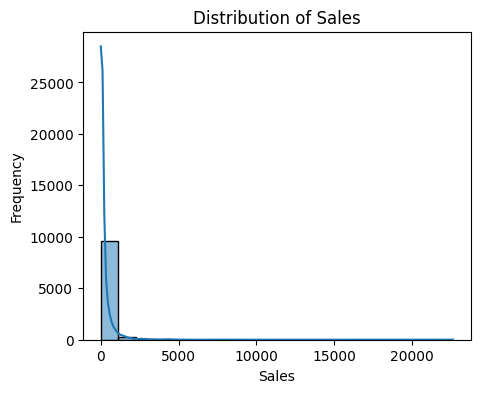

In [50]:
# Create a histogram showing the distribution of Sales
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.histplot(data=df,x="Sales",bins=20,kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Sales distribution was highly right-skewed, with most transactions having relatively low sales values and a small number of high-value transactions creating a long right tail.

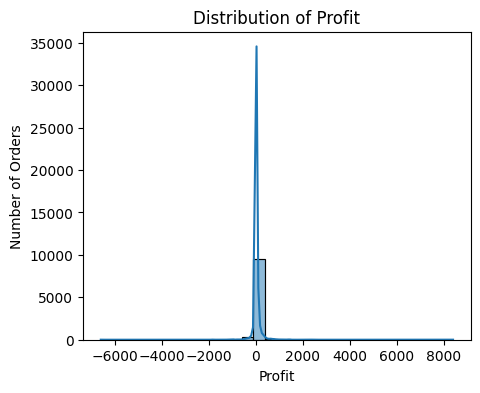

In [51]:
# Visualize the distribution of Profit
plt.figure(figsize=(5, 4))

sns.histplot(
    data=df,
    x="Profit",
    bins=30,
    kde=True
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")

plt.show()


Profit distribution was concentrated around zero, with both positive and negative values. A small number of transactions showed unusually high profits or losses, resulting in long tails on both sides of the distribution.

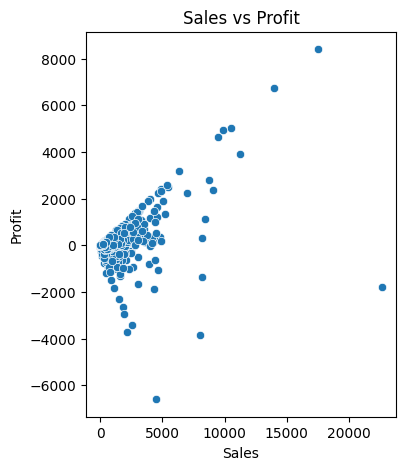

In [52]:
# Examine the relationship between Sales and Profit
plt.figure(figsize=(4, 5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

The point on the far right with approximately 22,000+ Sales and −1,800 Profit is particularly interesting. It suggests that high sales do not always guarantee high profit.

That's a valuable analytical insight for an AI-driven analysis system because the AI could explain why a high-sales observation might still have negative profit by investigating variables such as discount, cost, category, or product.

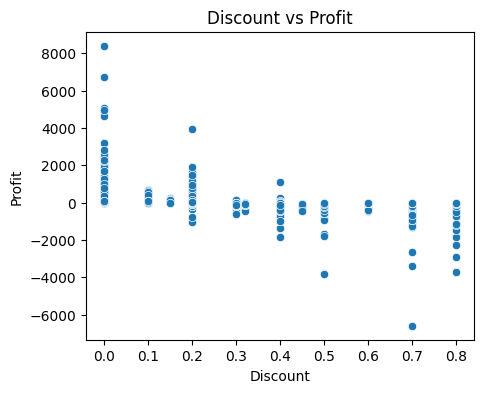

In [53]:
plt.figure(figsize=(5,4))

sns.scatterplot(data=df,x="Discount",y="Profit",)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Higher discount levels are generally associated with lower profitability, with substantial losses appearing at discounts of 50% and above. However, the relationship is not perfectly linear, suggesting that other factors also influence profit.

###Downloading Cleaned File

In [54]:
# Download the cleaned Superstore dataset as a CSV file
df.to_csv("superstore_cleaned.csv",index=False)

# Download the file to your computer
from google.colab import files
files.download("superstore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
# Check the number of rows in the cleaned dataset
print("Rows:", len(df))

# Check the number of columns
print("Columns:", len(df.columns))

# Check the column names
print(df.columns.tolist())

Rows: 9994
Columns: 26
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days', 'Year', 'Month', 'Month_Name', 'Year_Month']


In [56]:
df[['Order Date', 'Ship Date', 'Shipping Days', 'Year', 'Month']].head()

,Order Date,Ship Date,Shipping Days,Year,Month
0,2017-11-08,2017-11-11,259200000000000,2017,11
1,2017-11-08,2017-11-11,259200000000000,2017,11
2,2017-06-12,2017-06-16,345600000000000,2017,6
3,2016-10-11,2016-10-18,604800000000000,2016,10
4,2016-10-11,2016-10-18,604800000000000,2016,10


## Conclusion

The Superstore dataset was successfully cleaned, transformed, and analyzed using Python and Pandas.

The analysis identified important business patterns across sales, profit, products, customers, categories, regions, states, and time periods. It also helped identify profitable and loss-making areas and provided insights that can support business decision-making.

This project demonstrates practical skills in:

- Python
- Pandas
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Aggregation
- Feature Engineering
- Outlier Analysis
- Data Visualization
- Business Insights